# Download các thư viện cần thiết

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tạo hàm để đọc file parquet (đọc các file parquet - data sau khi được processed)

In [2]:
def read_parquet_user(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return user_chunk_df

In [3]:
def read_parquet_item(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    item_chunk_files = [file for file in files if 'item_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return item_chunk_df

In [4]:
def read_parquet_transaction(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    purchase_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    purchase_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_chunk_files]) if purchase_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return purchase_chunk_df

# Tạo hàm lưu file parquet sau mỗi task

In [5]:
def split_and_save_parquet(df, num_files, output_dir):
    """
    Tách DataFrame thành nhiều file Parquet và lưu vào thư mục đích.
    
    :param df: DataFrame cần tách
    :param num_files: Số lượng file Parquet muốn tách
    :param output_dir: Thư mục lưu các file Parquet
    """
    # Đảm bảo thư mục tồn tại
    os.makedirs(output_dir, exist_ok=True)
    
    # Tính số dòng mỗi file sẽ có
    num_rows = df.height
    rows_per_file = num_rows // num_files

    # Tách DataFrame thành các phần và lưu mỗi phần vào một file Parquet
    for i in range(num_files):
        start_row = i * rows_per_file
        # Đảm bảo phần cuối cùng sẽ chứa tất cả các dòng còn lại
        end_row = (i + 1) * rows_per_file if i < num_files - 1 else num_rows
        
        # Tách phần DataFrame
        split_df = df[start_row:end_row]
        
        # Lưu phần DataFrame vào file .parquet
        file_path = os.path.join(output_dir, f"sale_pers.user_chunk_{i}.parquet")
        split_df.write_parquet(file_path)
        print(f"Đã lưu file: {file_path}")

# Load dataset ban đầu

In [6]:
user = read_parquet_user(".././dataset")
user.head()

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false


# Tiền xử lý dữ liệu

1. Tạo bản sao dữ liệu user để tiền xử lý

Làm việc trên bản sao `user_pp` để tránh ghi đè trực tiếp lên dữ liệu gốc `user`.

In [7]:
user_pp = user.clone()
user_pp.head()


customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false


2. Loại bỏ các cột không hữu ích cho mô hình

- `sync_status_id`: cột kỹ thuật, không phản ánh đặc trưng người dùng.  
- `sync_error_message`: 100% giá trị `NULL`.  
- `user_id`: khoá định danh duy nhất, không nên dùng làm feature.  
- `is_deleted`: 100% `False`, không có độ biến thiên.


In [8]:
cols_drop_tech = [
    "sync_status_id",
    "sync_error_message",
    "user_id",
    "is_deleted",
]

user_pp = user_pp.drop([c for c in cols_drop_tech if c in user_pp.columns])
user_pp.head()

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,last_sync_date,region,location_name,install_app,install_date,district
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],datetime[μs],str,str,str,i64,str
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7"""
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức"""
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre"""
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1"""
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú"""


3. Rút gọn nhóm biến địa lý

Giữ lại:
- `location` (ID địa điểm, dạng i32)

Loại bỏ:
- `location_name`
- `region`
- `province`
- `district`

Lý do: các cột này có tương quan rất cao với `location` và chủ yếu là các phân cấp địa lý suy ra từ `location`, không thêm thông tin mới cho mô hình.


In [9]:
cols_drop_geo = [
    "location_name",
    "region",
    "province",
    "district",
]

user_pp = user_pp.drop([c for c in cols_drop_geo if c in user_pp.columns])
user_pp.head()

customer_id,gender,location,membership,timestamp,created_date,updated_date,last_sync_date,install_app,install_date
i32,str,i32,str,i64,datetime[μs],datetime[μs],datetime[μs],str,i64
14732,"""Nam""",155,"""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1306281600
15126,"""Nữ""",300,"""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1306281600
29718,"""Nữ""",157,"""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1582070400
30077,"""Nữ""",53,"""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1314230400
30085,"""Nữ""",660,"""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1314230400


4. Chuẩn hoá biến `gender`

- Lọc bỏ các dòng có gender = "khác" (và chuẩn hoá gender)

In [10]:
user_pp = (
    user_pp
    .filter(
        ~(
            user_pp["gender"]
            .cast(pl.Utf8)
            .str.to_lowercase()
            .str.strip_chars()
            .eq("khác")
        )
    )
)

# 2.2. Chuẩn hoá lại gender còn lại (Nam/Nam/Male/Female/...)
import re

def normalize_gender(x: str) -> str:
    if x is None:
        return None
    x = x.strip().lower()
    if x in ("nam", "male"):
        return "male"
    if x in ("nu", "nữ", "female"):
        return "female"
    # các giá trị lạ còn lại (nếu có) cho vào "other"
    return "other"

user_pp = user_pp.with_columns(
    pl.col("gender")
    .cast(pl.Utf8)
    .map_elements(normalize_gender, return_dtype=pl.Utf8)
    .alias("gender")
)


In [11]:
user_pp

customer_id,gender,location,membership,timestamp,created_date,updated_date,last_sync_date,install_app,install_date
i32,str,i32,str,i64,datetime[μs],datetime[μs],datetime[μs],str,i64
14732,"""male""",155,"""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1306281600
15126,"""female""",300,"""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1306281600
29718,"""female""",157,"""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1582070400
30077,"""female""",53,"""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1314230400
30085,"""female""",660,"""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1314230400
…,…,…,…,…,…,…,…,…,…
8800478,"""female""",186,"""Standard""",1749987601,2025-06-15 11:40:01.437,2025-09-23 17:43:56.503,2025-07-16 12:17:47.648696,"""In-Store""",1749945600
8814340,"""female""",385,"""Standard""",1750318260,2025-06-19 07:31:00.073,2025-06-19 07:31:00.337,2025-07-16 12:17:47.648696,"""In-Store""",1750291200
8810998,"""male""",1092,"""Standard""",1750234662,2025-06-18 08:17:42.230,2025-06-18 08:17:42.637,2025-07-16 12:17:47.648696,"""In-Store""",1750204800


5. Chuẩn hoá trường `install_app`

- Giữ các nguồn chính: `"In-Store"`, `"SPE"`, `"iOS"`, `"Android"`.  
- Gộp tất cả các nguồn hiếm còn lại vào `"Other App Source"` để giảm số lượng category và tránh nhiễu.


In [12]:
main_install_sources = {"In-Store", "SPE", "iOS", "Android"}

def normalize_install_app(x: str) -> str:
    if x is None:
        return None
    x = x.strip()
    if x in main_install_sources:
        return x
    return "Others"

user_pp = user_pp.with_columns(
    pl.col("install_app")
    .cast(pl.Utf8)
    .map_elements(normalize_install_app, return_dtype=pl.Utf8)
    .alias("install_app")
)

user_pp


customer_id,gender,location,membership,timestamp,created_date,updated_date,last_sync_date,install_app,install_date
i32,str,i32,str,i64,datetime[μs],datetime[μs],datetime[μs],str,i64
14732,"""male""",155,"""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1306281600
15126,"""female""",300,"""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1306281600
29718,"""female""",157,"""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1582070400
30077,"""female""",53,"""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1314230400
30085,"""female""",660,"""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2025-07-16 11:54:29.816986,"""In-Store""",1314230400
…,…,…,…,…,…,…,…,…,…
8800478,"""female""",186,"""Standard""",1749987601,2025-06-15 11:40:01.437,2025-09-23 17:43:56.503,2025-07-16 12:17:47.648696,"""In-Store""",1749945600
8814340,"""female""",385,"""Standard""",1750318260,2025-06-19 07:31:00.073,2025-06-19 07:31:00.337,2025-07-16 12:17:47.648696,"""In-Store""",1750291200
8810998,"""male""",1092,"""Standard""",1750234662,2025-06-18 08:17:42.230,2025-06-18 08:17:42.637,2025-07-16 12:17:47.648696,"""In-Store""",1750204800


## Xử lý các cột thời gian

hiện có các cột:

- timestamp – ingestion time → bỏ

- created_date – ngày tạo user → dùng để tính tuổi user

- updated_date – lần cập nhật hồ sơ cuối → bỏ

- last_sync_date – lần sync gần nhất → dùng để tính days_since_last_sync

- install_date – int64 (epoch seconds) → convert sang datetime rồi tính days_since_install

In [13]:
# Lấy ngày tham chiếu là ngày tạo user mới nhất
ref_date = (
    user_pp
    .select(pl.col("created_date").max().alias("ref_date"))
    ["ref_date"][0]
)
ref_date

datetime.datetime(2025, 9, 30, 22, 0, 36, 623000)

In [14]:
# Convert install_date → datetime
user_pp = user_pp.with_columns(
    pl.from_epoch(pl.col("install_date"), time_unit="s").alias("install_datetime")
)


In [15]:
user_pp = user_pp.with_columns(
    # tuổi user tính theo ngày
    (
        (ref_date - pl.col("created_date")).dt.cast_time_unit("us") 
        / pl.duration(days=1)
    ).alias("user_age_days"),

    # số ngày kể từ khi cài đặt
    (
        (ref_date - pl.col("install_datetime")).dt.cast_time_unit("us") 
        / pl.duration(days=1)
    ).alias("days_since_install"),

    # số ngày kể từ lần sync gần nhất
    (
        (ref_date - pl.col("last_sync_date")).dt.cast_time_unit("us") 
        / pl.duration(days=1)
    ).alias("days_since_last_sync"),
)

In [16]:
cols_drop_time = [
    "timestamp",
    "updated_date",
    # nếu bạn muốn bỏ luôn raw install_date, dùng dòng dưới:
    "install_date",
]

user_pp = user_pp.drop([c for c in cols_drop_time if c in user_pp.columns])

In [17]:
user_pp.head()

customer_id,gender,location,membership,created_date,last_sync_date,install_app,install_datetime,user_age_days,days_since_install,days_since_last_sync
i32,str,i32,str,datetime[μs],datetime[μs],str,datetime[μs],f64,f64,f64
14732,"""male""",155,"""Standard""",2011-05-25 21:11:51.677,2025-07-16 11:54:29.816986,"""In-Store""",2011-05-25 00:00:00,5242.033854,5242.917091,76.420912
15126,"""female""",300,"""Standard""",2011-05-25 21:11:51.677,2025-07-16 11:54:29.816986,"""In-Store""",2011-05-25 00:00:00,5242.033854,5242.917091,76.420912
29718,"""female""",157,"""Standard""",2011-07-31 15:38:12.750,2025-07-16 11:54:29.816986,"""In-Store""",2020-02-19 00:00:00,5175.265554,2050.917091,76.420912
30077,"""female""",53,"""Standard""",2011-08-25 20:06:22.797,2025-07-16 11:54:29.816986,"""In-Store""",2011-08-25 00:00:00,5150.079327,5150.917091,76.420912
30085,"""female""",660,"""Standard""",2011-08-25 22:07:04.267,2025-07-16 11:54:29.816986,"""In-Store""",2011-08-25 00:00:00,5149.995513,5150.917091,76.420912


Ý nghĩa các feature thời gian

- **user_age_days**: số ngày kể từ khi người dùng được tạo tài khoản → phản ánh vòng đời người dùng.
- **days_since_install**: số ngày kể từ khi người dùng cài ứng dụng → phản ánh mức độ gắn bó kể từ lúc bắt đầu.
- **days_since_last_sync**: số ngày kể từ lần đồng bộ gần nhất → proxy mức độ hoạt động (active/inactive) của người dùng.

Bỏ đi giá trị `giờ`, `phút`, `giây` trong các cột thời gian, chỉ giữ lại `ngày`, `tháng`, `năm` để tính toán sự khác biệt ngày tháng.

In [18]:
user_pp = user_pp.with_columns([
    pl.col("install_datetime").dt.date().alias("install_datetime"),
    pl.col("last_sync_date").dt.date().alias("last_sync_date"),
    pl.col("created_date").dt.date().alias("created_date"),
])

In [19]:
user_pp.head()

customer_id,gender,location,membership,created_date,last_sync_date,install_app,install_datetime,user_age_days,days_since_install,days_since_last_sync
i32,str,i32,str,date,date,str,date,f64,f64,f64
14732,"""male""",155,"""Standard""",2011-05-25,2025-07-16,"""In-Store""",2011-05-25,5242.033854,5242.917091,76.420912
15126,"""female""",300,"""Standard""",2011-05-25,2025-07-16,"""In-Store""",2011-05-25,5242.033854,5242.917091,76.420912
29718,"""female""",157,"""Standard""",2011-07-31,2025-07-16,"""In-Store""",2020-02-19,5175.265554,2050.917091,76.420912
30077,"""female""",53,"""Standard""",2011-08-25,2025-07-16,"""In-Store""",2011-08-25,5150.079327,5150.917091,76.420912
30085,"""female""",660,"""Standard""",2011-08-25,2025-07-16,"""In-Store""",2011-08-25,5149.995513,5150.917091,76.420912


Lưu data đã được xử lý xuống folder processed_data.

In [20]:
split_and_save_parquet(user_pp, num_files=10, output_dir="./preprocessed-data")

Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_0.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_1.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_2.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_3.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_4.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_5.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_6.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_7.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_8.parquet
Đã lưu file: ./preprocessed-data\sale_pers.user_chunk_9.parquet


# Kiểm chứng dữ liệu sau bước tiền xử lý

In [24]:
import polars as pl

def describe_categorical(df: pl.DataFrame, col: str):
    """
    Trả về frequency table cho 1 cột categorical.
    Gồm:
    - value
    - count
    - pct (tỷ lệ %)
    """
    counts = (
        df
        .group_by(col)
        .agg(pl.count().alias("count"))
        .with_columns(
            (pl.col("count") / pl.col("count").sum()).alias("pct")
        )
        .sort("count", descending=True)
    )
    return counts


In [29]:
categorical_cols = [
    "gender",
    "install_app",
]

results = {}

for col in categorical_cols:
    results[col] = describe_categorical(user_pp, col)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8872\1072091738.py:14: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


In [27]:
from matplotlib import cm


def plot_bar_colorful(df_pl, col, top_k=None, save_path=None):
    df = df_pl.to_pandas()

    if top_k is not None:
        df = df.head(top_k)

    if "pct" in df.columns:
        df = df.sort_values("pct", ascending=False)

    n = len(df)
    colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))

    figsize = (12, 5) if col in ("gender", "membership", "install_app") else (30, 5)

    plt.figure(figsize=figsize)
    plt.bar(df[col].astype(str), df["pct"], color=colors)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8872\1076344465.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


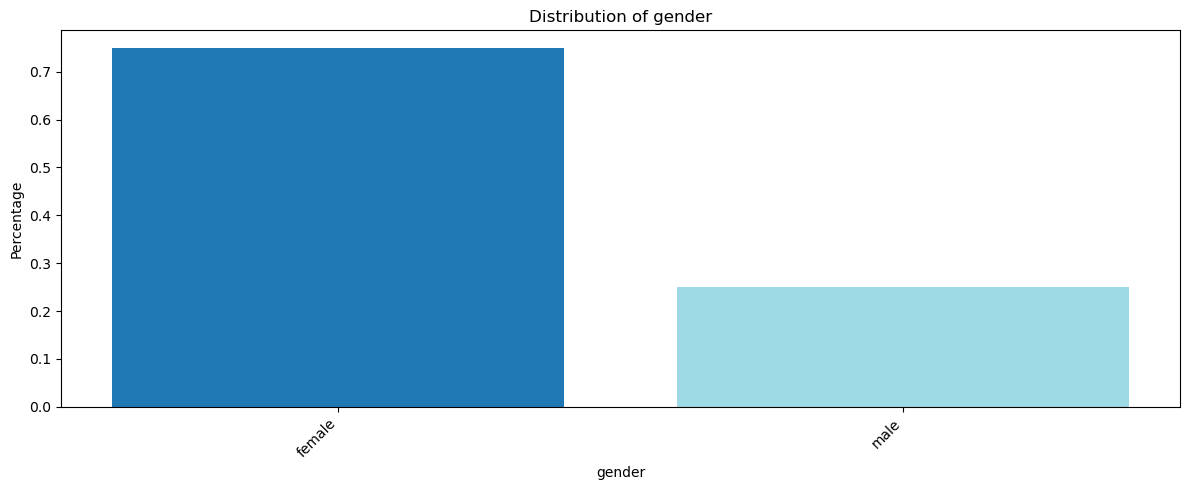

C:\Users\Admin\AppData\Local\Temp\ipykernel_8872\1076344465.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


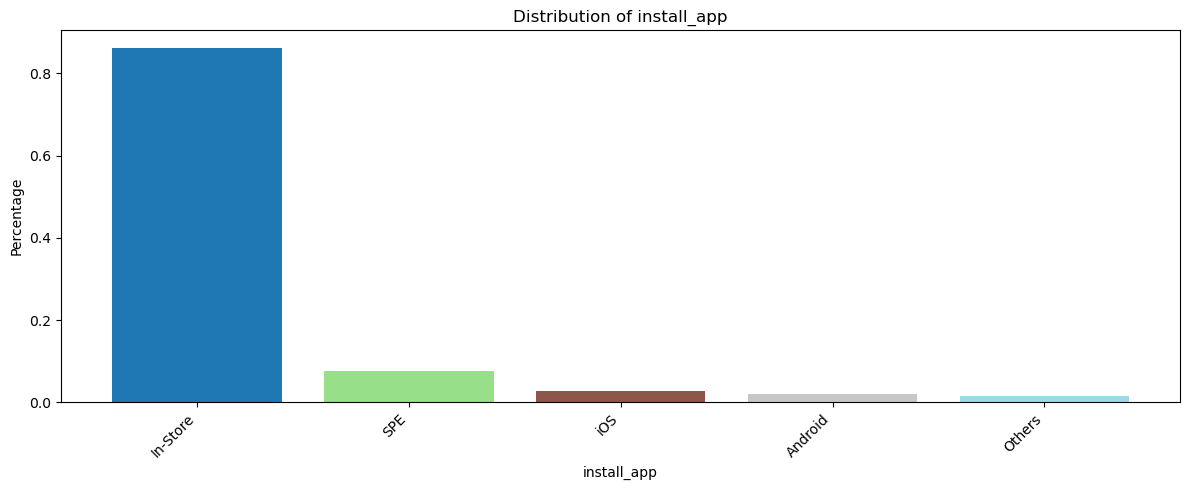

In [30]:
bar_cols = ["gender", "install_app"]

for col in bar_cols:
    plot_bar_colorful(results[col], col)